## CNN
A Convolutional Neural Network (CNN) is a type of deep learning model designed to process and analyze images. It's especially good at recognizing patterns, like edges, shapes, textures, and objects in images.


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version:      {np.__version__}")
print(f"Seaborn version:    {sns.__version__}")
print(f"Pandas version:     {pd.__version__}")

TensorFlow version: 2.15.0
NumPy version:      1.26.4
Seaborn version:    0.13.2
Pandas version:     2.2.2


# Step1: Data collection

In [3]:
#  Load the MNIST dataset. It has 60,000 images for training and 10,000 images for testing.

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [4]:
# Display the shape of the dataset

print(f"x_train shape: {x_train.shape}")  # (60000, 28, 28) -> 60000 images of 28x28 pixels
print(f"y_train shape: {y_train.shape}")  # (60000,)

print(f"x_test shape: {x_test.shape}")    # (10000, 28, 28)
print(f"y_test shape: {y_test.shape}")    # (10000,)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [5]:
# Lets look at the first image data and also plot it. We are trying to understand the image data
img_idx=0

print("Shape:", x_train[img_idx].shape)
print("--------------------")
np.set_printoptions(linewidth=150, precision=2, suppress=True)  # Adjust formatting
print(x_train[img_idx])
print("+++++++++++++++++++")
print("Label: ", y_train[img_idx])

Shape: (28, 28)
--------------------
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 2

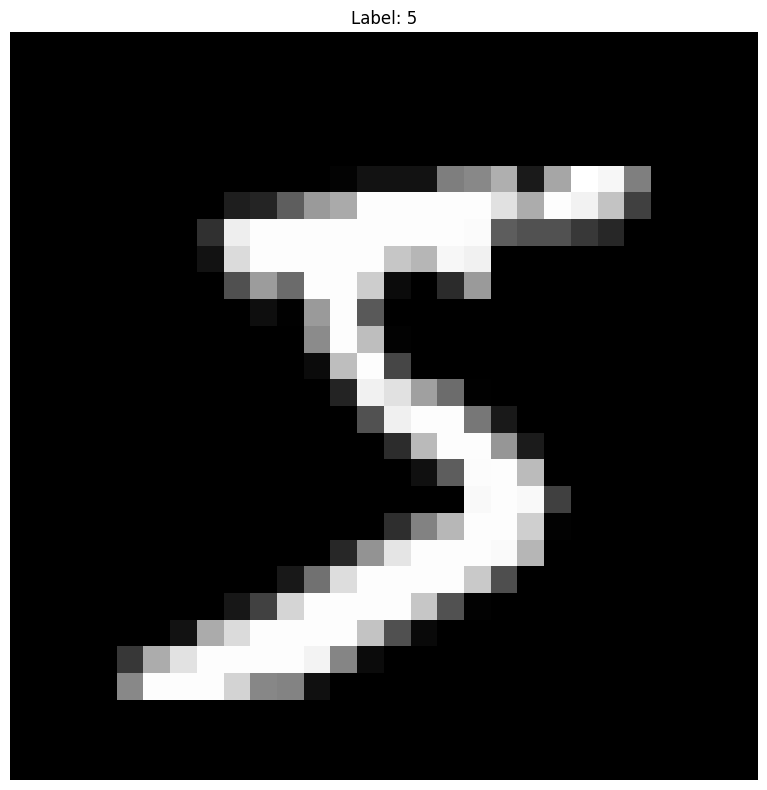

In [6]:
# 2) 
plt.figure(figsize=(8,8))  # Set the figure size

plt.imshow(x_train[img_idx],
           cmap='gray' # # Display the image in grayscale. comment it out if u want to see color
)
plt.title(f"Label: {y_train[img_idx]}")  # Set the title as the label
plt.axis('off')  # Turn off axis
plt.tight_layout()
plt.show()

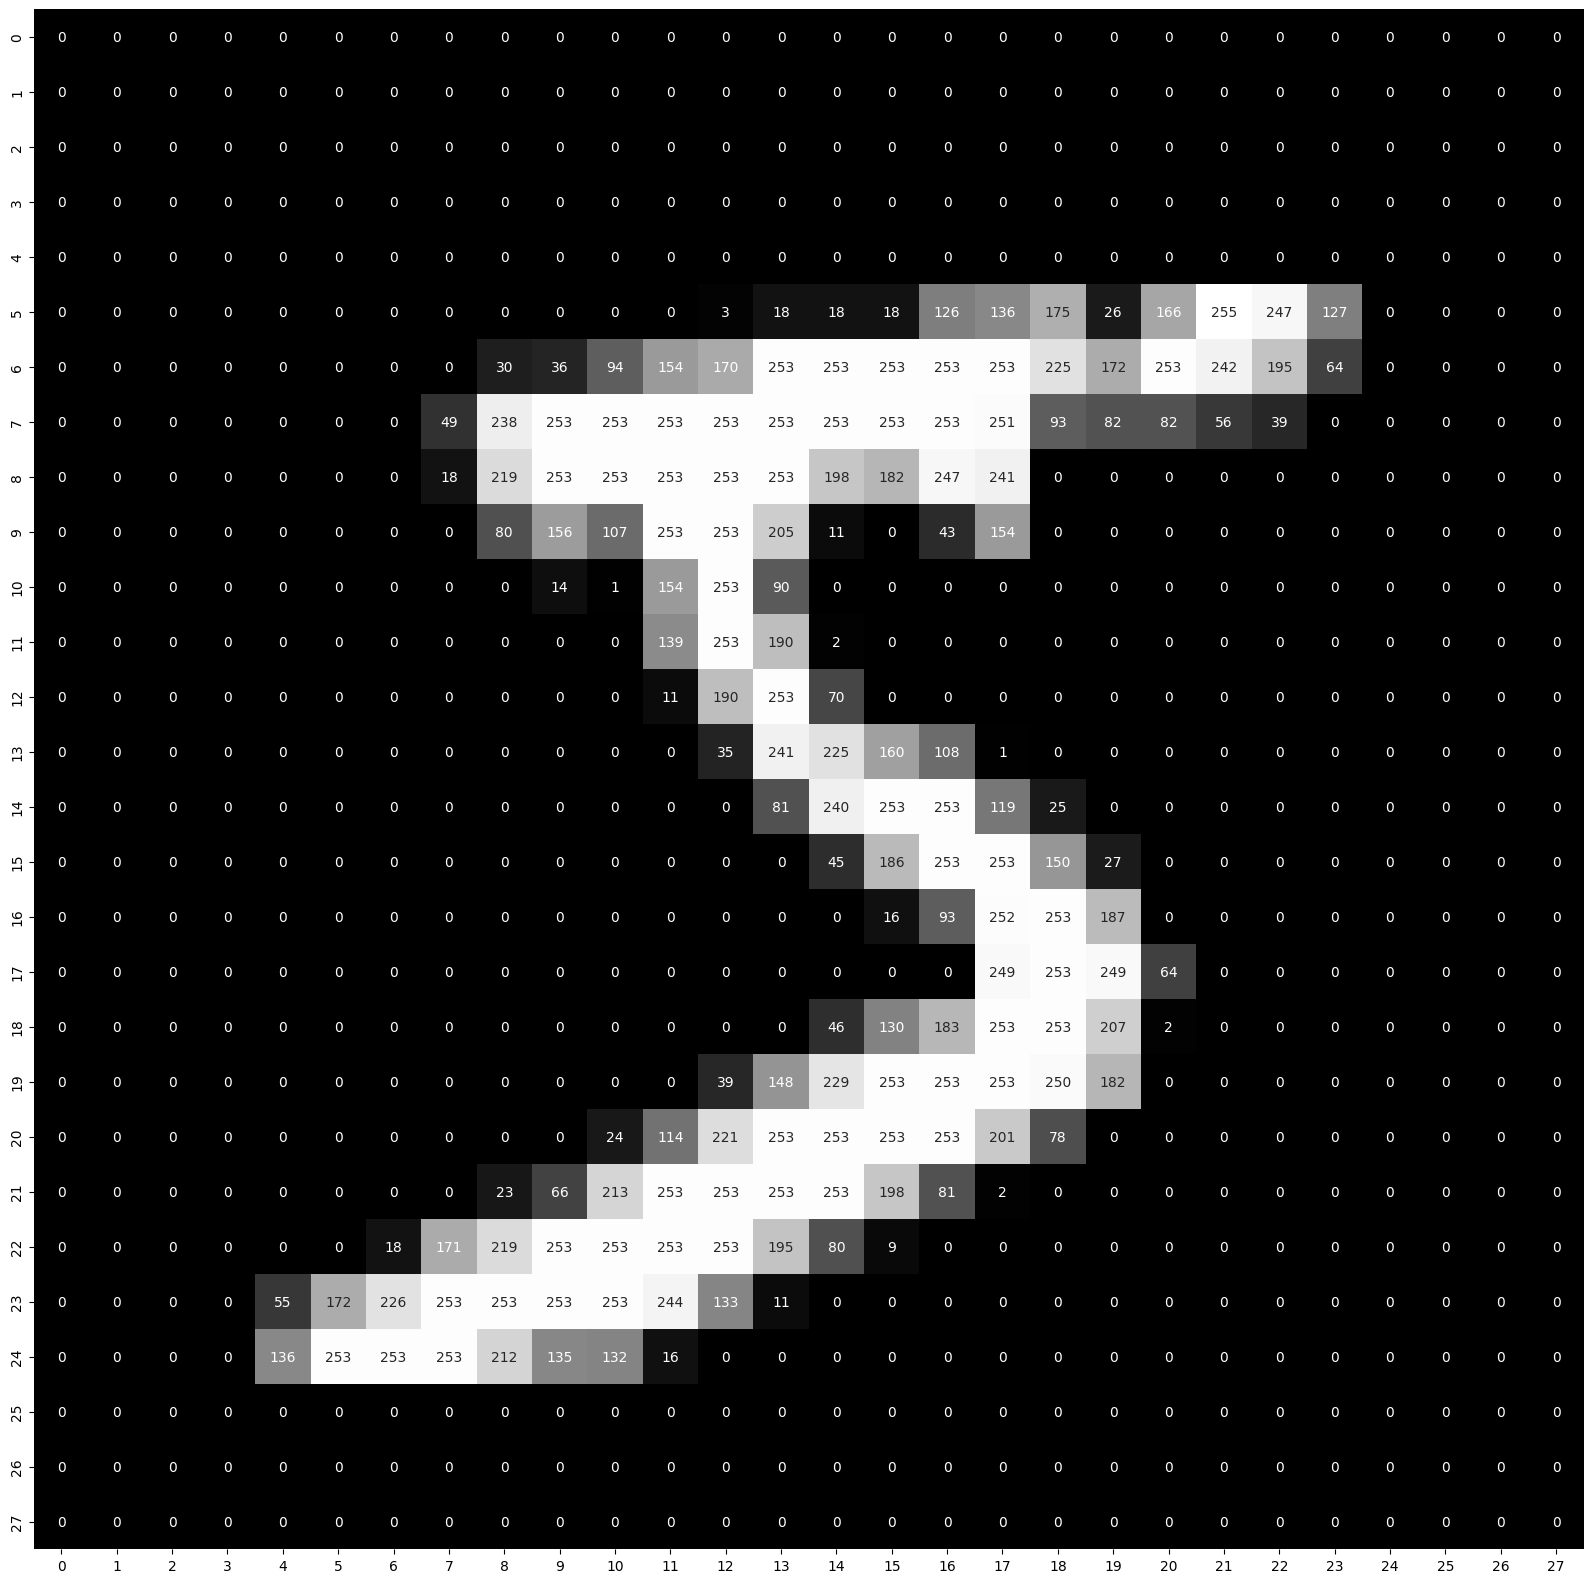

In [7]:
# 3) Lets visualize above using heatmap.

plt.figure(figsize=(20, 20))
# sns.heatmap(x_train[img_idx], annot=True, cmap="gray", cbar=False)
sns.heatmap(x_train[img_idx], annot=True, fmt="d", cmap="gray", cbar=False)
plt.show()

Lets understand above data. The first image, which is 5, has 28 rows and 28 columns. It is so because this is image size 28 X 28. Each value in the row,col is from 0-255, which is color range.

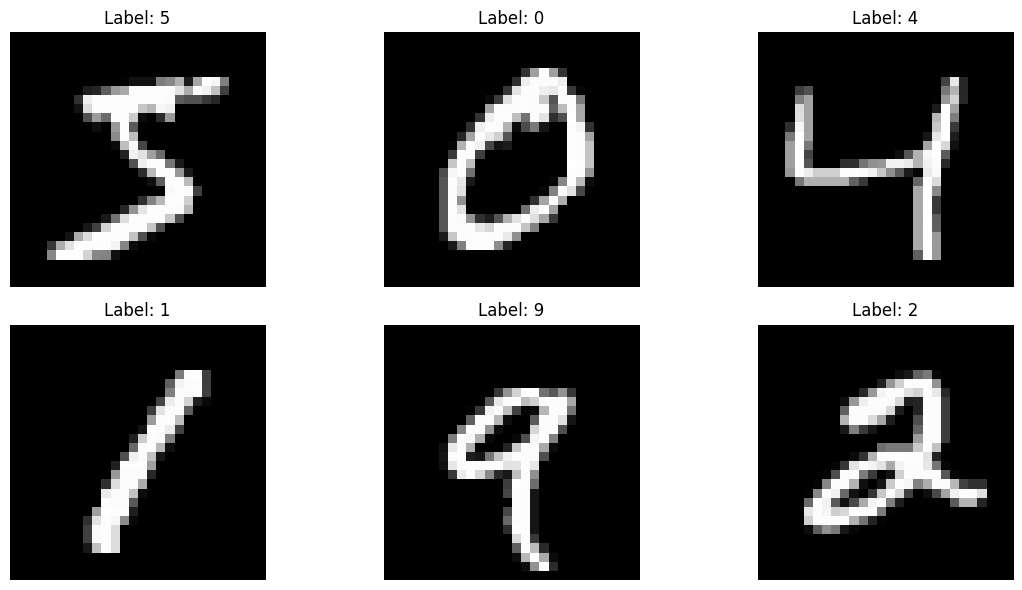

In [8]:
# Display the first 6 images with their labels

plt.figure(figsize=(12, 6))  # Set the figure size
for i in range(6):
    plt.subplot(2, 3, i + 1)  # Create a 2x3 grid for 6 images
    plt.imshow(x_train[i], cmap='gray')  # Display the image in grayscale
    plt.title(f"Label: {y_train[i]}")  # Set the title as the label
    plt.axis('off')  # Turn off axis
plt.tight_layout()
plt.show()

In [9]:
# Divide all numbers by 255: This would bring all numbers in range 0 - 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape the data to include a channel dimension (required by Conv2D)
# Each image becomes (28, 28, 1) instead of (28, 28)
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


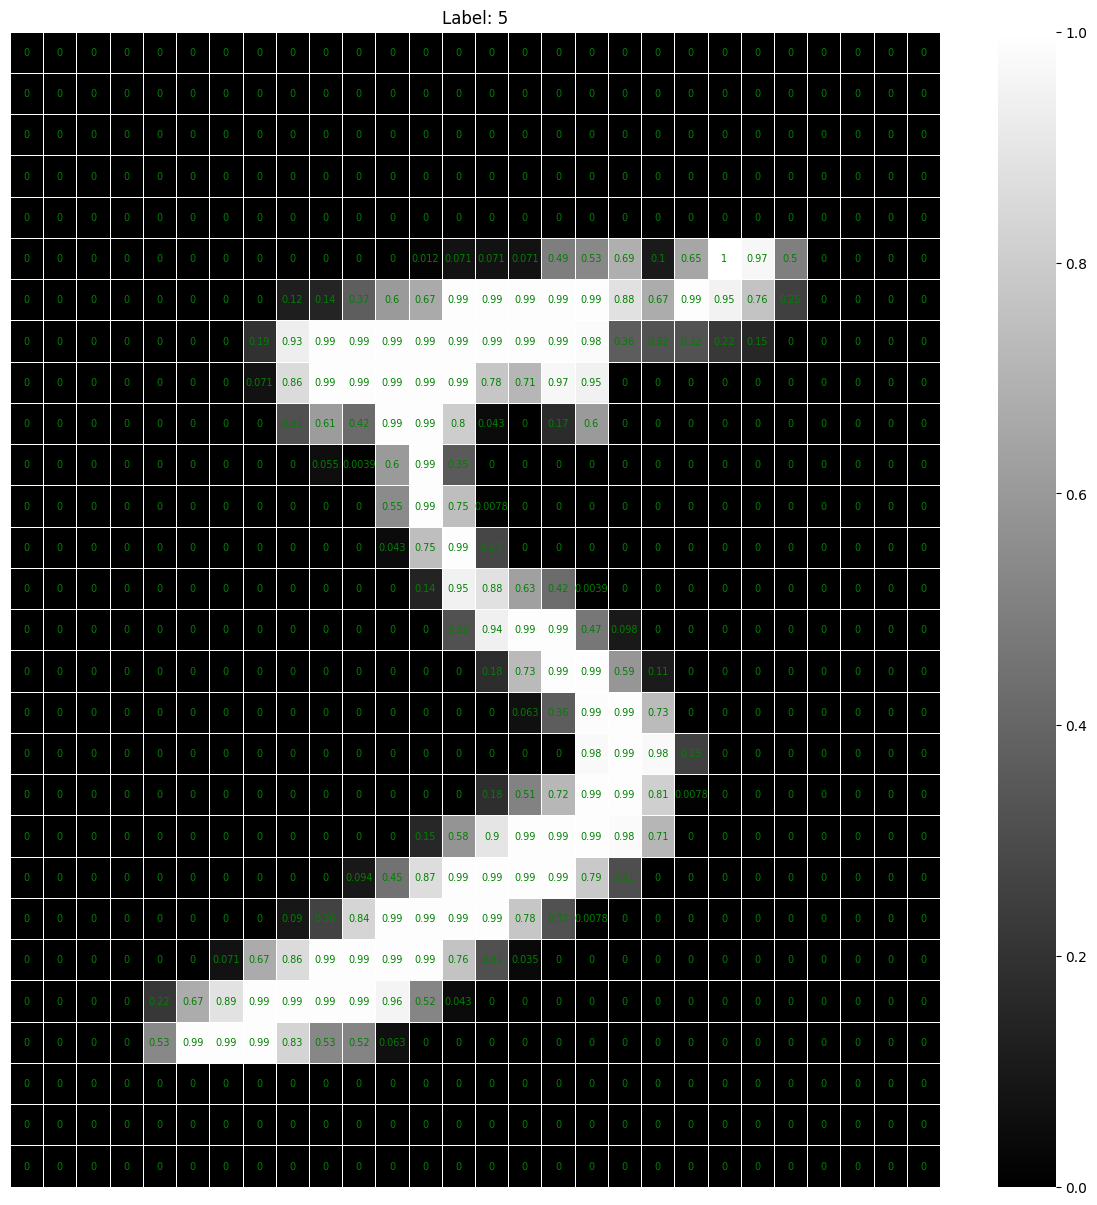

In [10]:
# Lets view the normalized data.

# Extract the first image and remove the extra dimension at the end
image = x_train[0].squeeze()

plt.figure(figsize=(15, 15))
sns.heatmap(image, annot=True,
            # fmt=".2f", # on local machine, remove the comment to see output
            cmap="gray",
            linewidths=0.5, cbar=True,
            annot_kws={"size": 7, "color": "green"})  # Smaller font, red color for better contrast

plt.axis("off")  # Hide axis for clarity
plt.title(f"Label: {y_train[0]}")
plt.show()

# Step2: Create the CNN model

In [11]:
# The model extracts features using convolutional layers, reduces dimensions using pooling,
# and predicts digit classes using dense layers.
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(28, 28, 1)),       # First convolutional layer
    layers.MaxPooling2D((2, 2)),                  # First pooling layer

    layers.Conv2D(64, (3, 3), activation='relu'), # Second convolutional layer
    layers.MaxPooling2D((2, 2)),                  # Second pooling layer

    layers.Flatten(),                             # Flatten 3D features to 1D
    
    layers.Dense(64, activation='relu'),          # Fully connected layer, 64 neurons in hidden layer
    
    layers.Dense(10, activation='softmax')        # Output layer (10 classes)
])


In [12]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 64)                1

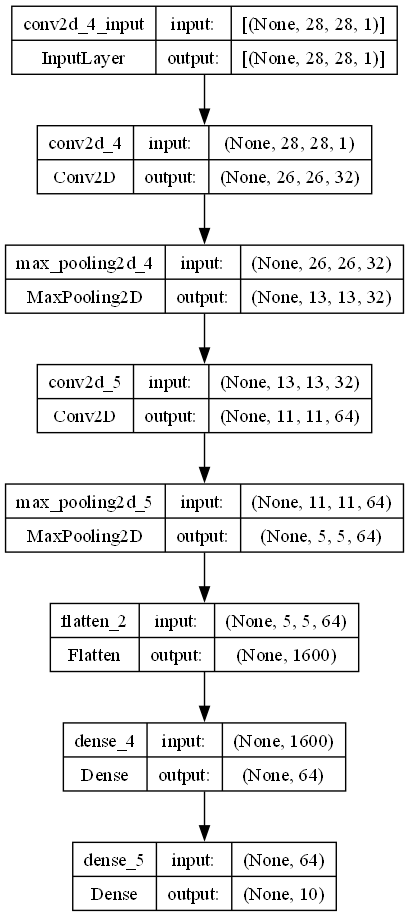

In [16]:
from tensorflow.keras.utils import plot_model

plot_model(model, 
           to_file='model.png', 
           show_shapes=True, 
           show_layer_names=True,
           rankdir='TB',  # Changes layout from vertical (TB) to horizontal (LR)
           dpi=100        # Increases resolution (dots per inch)
)

## Details of Each Layer shown above

1. Input Layer
- Layer (Type): conv2d (2D Convolutional Layer)
- Output Shape: (None, 26, 26, 32)
- None: Refers to the batch size (dynamic).
- 26, 26: The spatial dimensions of the output feature map (reduced from 28x28 due to a 3x3 filter).
- 32: Number of filters in the layer.
- Param #: Calculated as (total weights + biases) = (3 * 3 * 1 * 32) + 32 = 320

2. Pooling Layer
- Layer (Type): max_pooling2d
- Output Shape: (None, 13, 13, 32)
- Spatial dimensions are halved because of the 2x2 pooling window.
- Param #: 0 (No trainable parameters in pooling layers).

3. Second Convolutional Layer
- Layer (Type): conv2d_1
- Output Shape: (None, 11, 11, 64): Further reduced spatial dimensions due to another 3x3 filter.
- 64: Number of filters.
- Param #: Calculated as (3 * 3 * 32 * 64) + 64  = 18,496

and so on

# Step 3: Compile the model

In [17]:
# Use Sparse Categorical Crossentropy for multi-class classification
# Adam optimizer is widely used and efficient for CNNs

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 4: Train the model: Took 2 minutes

In [11]:
# Train on the training data and validate on a portion of it

history = model.fit(x_train, y_train, 
                    epochs=3, 
                    batch_size=32, 
                    validation_split=0.1
    )

Epoch 1/3


1688/1688 [==============================] - 21s 11ms/step - loss: 0.1307 - accuracy: 0.9597 - val_loss: 0.0545 - val_accuracy: 0.9860
Epoch 2/3
1688/1688 [==============================] - 19s 11ms/step - loss: 0.0443 - accuracy: 0.9858 - val_loss: 0.0405 - val_accuracy: 0.9875
Epoch 3/3
1688/1688 [==============================] - 18s 11ms/step - loss: 0.0310 - accuracy: 0.9898 - val_loss: 0.0304 - val_accuracy: 0.9915


In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two subplots: one for Accuracy and one for Loss
plt.figure(figsize=(12, 5))

# 1. Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# Step 5: Evaluate the model

In [12]:
# Evaluate performance on the test set

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"Test accuracy: {test_acc:.2f}")

313/313 - 1s - loss: 0.0215 - accuracy: 0.9927 - 1s/epoch - 4ms/step
Test accuracy: 0.99


In [13]:
# Evaluate performance on the train set

train_loss, train_acc = model.evaluate(x_train, y_train, verbose=2)

print(f"Train accuracy: {train_acc:.2f}")

1875/1875 - 7s - loss: 0.0153 - accuracy: 0.9955 - 7s/epoch - 4ms/step
Train accuracy: 1.00


## Observation:
- Not much difference between train and test accuracy. So,  there is no overfitting

# Step 6: Visualize predictions on few test images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


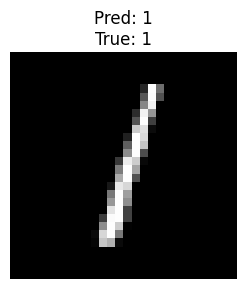

In [20]:
# Select one image
image_index = 15

prediction = model.predict(x_test[image_index:image_index + 1]) 
print("prediction:", prediction) # probabilities

predicted_label = prediction.argmax(axis=1)[0]  # Get the predicted digit
print("predicted_label:", predicted_label)

true_label = y_test[image_index]  # Actual label

# Plot the test image with predicted and true label
plt.figure(figsize=(3, 3))
plt.imshow(x_test[image_index].squeeze(), cmap='gray')  # Remove the channel dimension
plt.title(f"Pred: {predicted_label}\nTrue: {true_label}")
plt.axis('off')
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


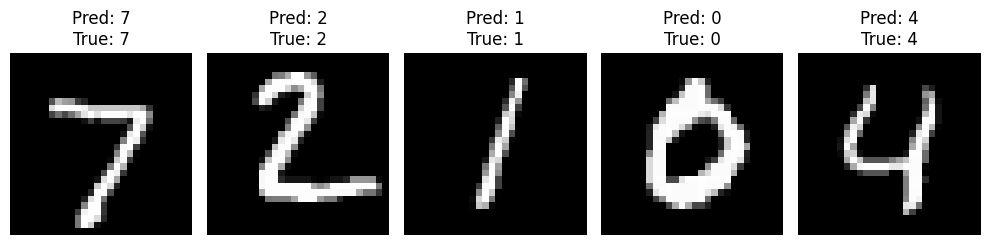

In [17]:
# Select the first 5 test images for prediction
predictions = model.predict(x_test[:5])
predicted_labels = predictions.argmax(axis=1)  # Get the predicted digit
true_labels = y_test[:5]  # Actual labels

# Plot the first 5 test images along with predicted and true labels
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')  # Remove the channel dimension for visualization
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {true_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


# Step7: Saving and Loading Models
Once a model is trained, you can save it to disk and load it later for inference or retraining.

Example:

In [ ]:
# 1) Save the model

model.save("model.keras")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9857 - loss: 0.0455
Loaded model test accuracy: 0.988099992275238



1/1 [==============================] - 0s 155ms/step
prediction: [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]
predicted_label: 5


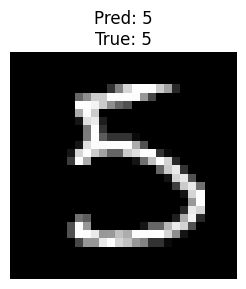

In [13]:
# 2) Load the model back and test it on one image

loaded_model = tf.keras.models.load_model("model.keras")

# Select one image
image_index = 15

prediction = loaded_model.predict(x_test[image_index:image_index + 1]) 
print("prediction:", prediction) # probabilities

predicted_label = prediction.argmax(axis=1)[0]  # Get the predicted digit
print("predicted_label:", predicted_label)

true_label = y_test[image_index]  # Actual label

# Plot the test image with predicted and true label
plt.figure(figsize=(3, 3))
plt.imshow(x_test[image_index].squeeze(), cmap='gray')  # Remove the channel dimension
plt.title(f"Pred: {predicted_label}\nTrue: {true_label}")
plt.axis('off')
plt.tight_layout()

# OPTIONAL: Try following model with different padding (5, 5)
- You will get similar results

In [ ]:
# Step 2: Create the CNN model
model = models.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),  # First convolutional layer
    layers.MaxPooling2D((2, 2)),                                           # First pooling layer

    layers.Conv2D(64, (5, 5), activation='relu'),                          # Second convolutional layer
    layers.MaxPooling2D((2, 2)),                                           # Second pooling layer

    layers.Flatten(),                                                      # Flatten 3D features to 1D
    
    layers.Dense(64, activation='relu'),                                   # Fully connected layer, 64 neurons in hidden layer
    
    layers.Dense(10, activation='softmax')                                 # Output layer (10 classes)
])
